Central tendency for all columns:
CO(GT) -> Mean: 2.153, Median: 2.153, Mode: 2.153
PT08.S1(CO) -> Mean: 1099.833, Median: 1075.000, Mode: 1099.833
NMHC(GT) -> Mean: 218.812, Median: 218.812, Mode: 218.812
C6H6(GT) -> Mean: 10.083, Median: 8.600, Mode: 10.083
PT08.S2(NMHC) -> Mean: 939.153, Median: 923.000, Mode: 939.153
NOx(GT) -> Mean: 246.897, Median: 229.000, Mode: 246.897
NO2(GT) -> Mean: 113.091, Median: 113.091, Mode: 113.091
PT08.S4(NO2) -> Mean: 1456.265, Median: 1456.265, Mode: 1456.265
PT08.S5(O3) -> Mean: 1022.906, Median: 983.000, Mode: 1022.906
T -> Mean: 18.346, Median: 18.300, Mode: 18.348
RH -> Mean: 49.234, Median: 49.234, Mode: 49.234
AH -> Mean: 1.026, Median: 1.015, Mode: 1.026


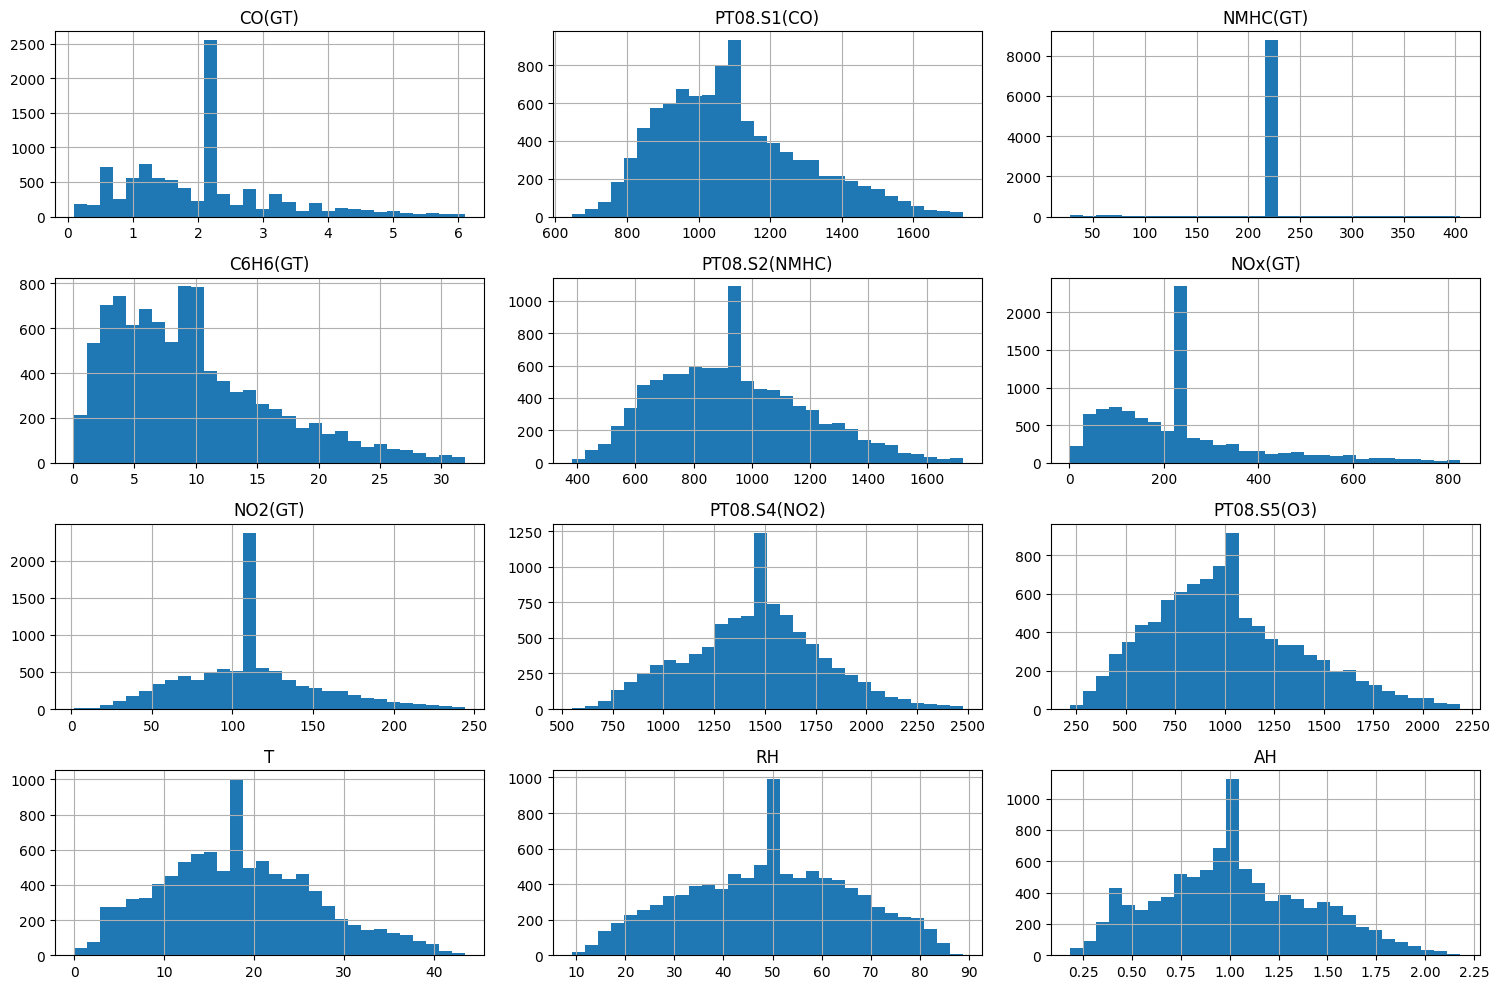

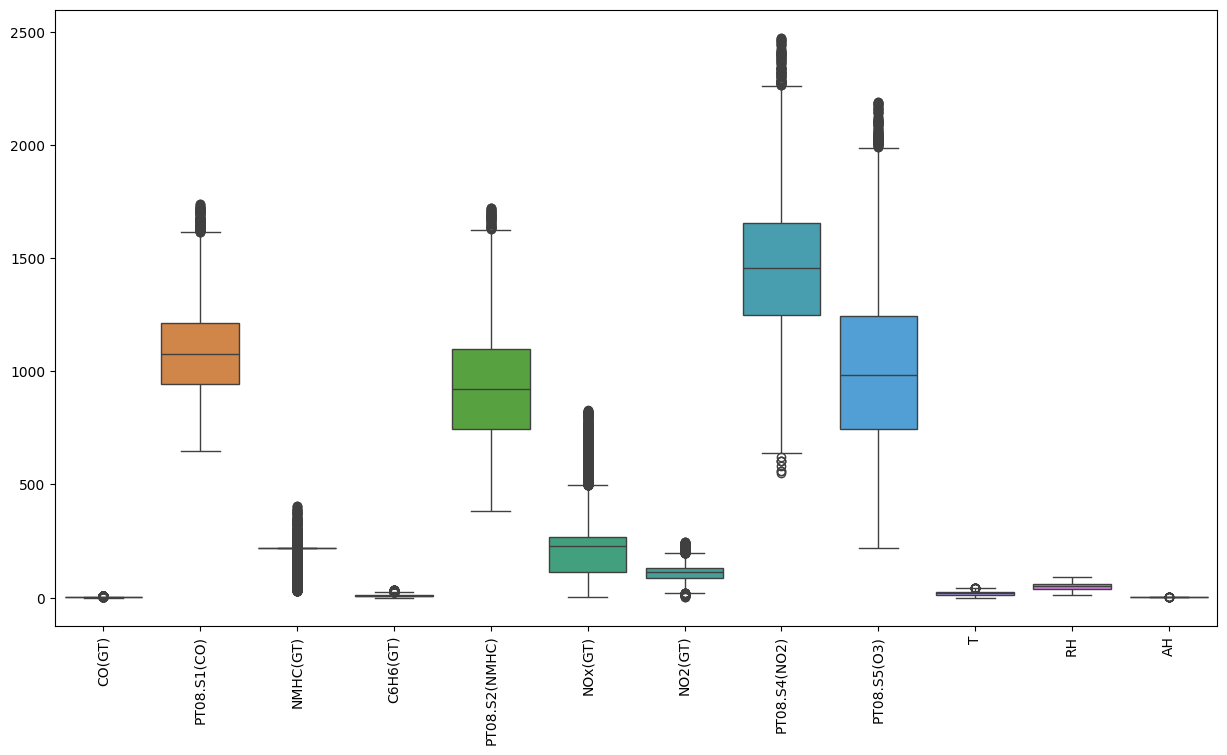

✅ Dataset cleaned, outliers handled, NaNs filled, and saved successfully!


In [ ]:
# Step 1: Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Excel file (already uploaded in Files panel)
# Replace the filename with your uploaded file name if different
df = pd.read_excel("Data Science Project.xlsx")

# Step 3: Convert numeric columns
cols_to_convert = ['CO(GT)','PT08.S1(CO)','NMHC(GT)','C6H6(GT)',
                   'PT08.S2(NMHC)','NOx(GT)','NO2(GT)','PT08.S4(NO2)',
                   'PT08.S5(O3)','T','RH','AH']  # removed PT08.S3(NOx)

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 4: Central tendency
print("Central tendency for all columns:")
for col in cols_to_convert:
    print(f"{col} -> Mean: {df[col].mean():.3f}, Median: {df[col].median():.3f}, Mode: {df[col].mode()[0]:.3f}")

# Step 5: Detect outliers using 3*STD rule
for col in cols_to_convert:
    mean = df[col].mean()
    std = df[col].std()
    df[col + '_outlier'] = df[col].apply(lambda x: 'Outlier' if x > mean + 3*std or x < mean - 3*std else '')

# Step 6: Replace outliers with median
for col in cols_to_convert:
    median = df[col].median()
    df.loc[df[col + '_outlier'] == 'Outlier', col] = median

# Step 7: Fill remaining NaNs with median
for col in cols_to_convert:
    df[col] = df[col].fillna(df[col].median())

# Step 8: Drop mostly-empty column if exists (PT08.S3(NOx))
if 'PT08.S3(NOx)' in df.columns:
    df = df.drop(columns=['PT08.S3(NOx)'])

# Step 9: Preview cleaned dataset
df.head()

# Step 10: Histograms
df[cols_to_convert].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

# Step 11: Boxplots
plt.figure(figsize=(15,8))
sns.boxplot(data=df[cols_to_convert])
plt.xticks(rotation=90)
plt.show()

# Step 12: Save cleaned dataset
df.to_csv("Data_Science_Project_cleaned.csv", index=False)
df.to_excel("Data_Science_Project_cleaned.xlsx", index=False)

print("✅ Dataset cleaned, outliers handled, NaNs filled, and saved successfully!")